In [1]:
import glob
import joblib

import numpy as np
from numpy import load
from scipy.signal import savgol_filter
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

from novami.io.file import read_pl, write_pl
from novami.visualize.utils import *

### Figure 1: ECG and AP

✔ Matplotlib is now using: Arial


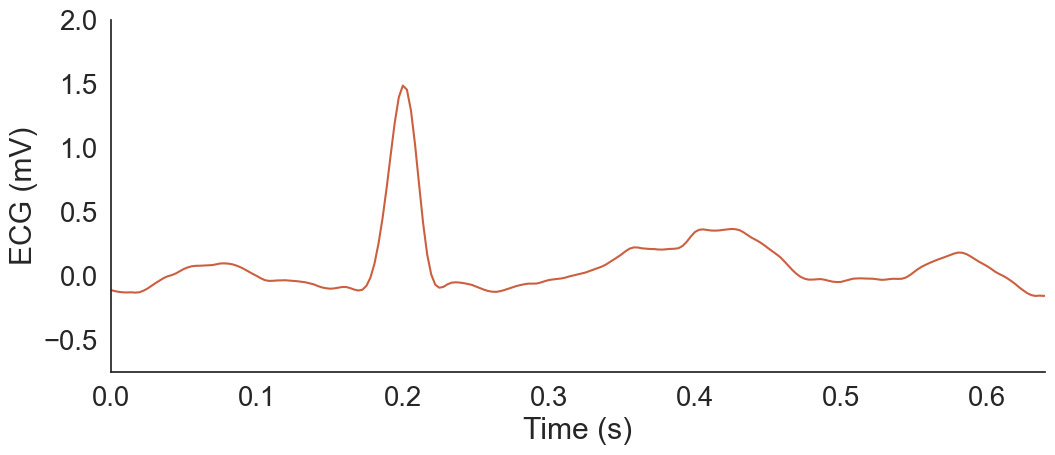

In [28]:
spp = six_point_palette()
sns.set_style('white')
sns.set_context('notebook', font_scale=1.8)
set_font()

# Data normally available under scipy.datasets.electrocardiogram, alas proxy issues...
with load('../data/ecg/ecg.dat') as file:
    ecg = file['ecg'].astype('int')

ecg = (ecg - 1024) / 200.0  # in mV

frequency = 360
time_data = np.arange(ecg.size) / frequency  # in seconds

df = pl.DataFrame({'Time': time_data, 'ECG': ecg})
df = df.filter(pl.col('Time').is_between(6.05, 6.7)).with_columns(
    (pl.col('Time') - pl.col('Time').min()).alias('Time')
)

time_arr = df['Time'].to_numpy()
ecg_arr = df['ECG'].to_numpy()

coeffs = np.polyfit(time_arr, ecg_arr, deg=1)
baseline = np.polyval(coeffs, time_arr)
ecg_detrended = ecg_arr - baseline

ecg_detrended = ecg_detrended - np.median(ecg_detrended)

WINDOW_LENGTH = 11
POLY_ORDER = 2
ecg_smooth = savgol_filter(ecg_detrended, window_length=WINDOW_LENGTH, polyorder=POLY_ORDER)

df_corrected = pl.DataFrame({
    'Time': time_arr,
    'ECG': ecg_smooth
})

g = sns.relplot(df_corrected, x='Time', y='ECG', kind='line', aspect=2.2, color=spp[-1])
g.set_axis_labels('Time (s)', 'ECG (mV)')
plt.xlim(0, 0.64)
plt.ylim(-0.75, 2)


plt.tight_layout()
plt.savefig('../figures/ecg_example.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Data generated using modified O'Hara-Rudy model from CiPA (w/o the hERG hill fitting), but rescaled to fit better with the ECG plot
aps = read_pl('../data/ecg/AP_trace_control.csv')

# Extract baseline
baseline = aps.filter(pl.col('time').is_between(1000, 1260))
baseline = baseline.with_columns(
    (pl.col('time') - 1000).alias('time')
)

# Add baseline before the actual AP
aps = aps.with_columns((pl.col('time') + 260).alias('time'))
aps = pl.concat([baseline, aps])

# Rescale to match with the ECG (values still physiological)
aps = aps.with_columns(
    (pl.col('time') / 1.3).alias('time')
)

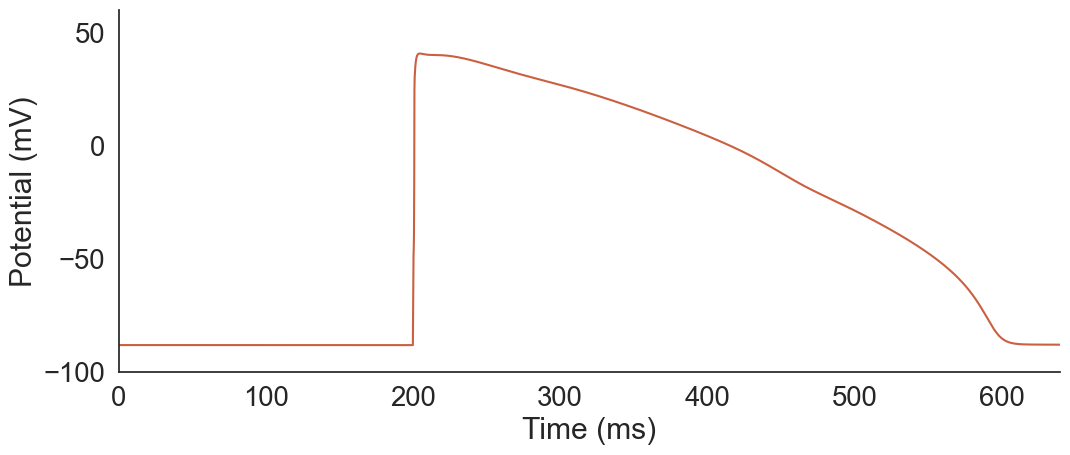

In [30]:
sns.relplot(aps.filter(pl.col('time')<1000), x='time', y='v', kind='line', aspect=2.2, color=spp[-1])
plt.xlabel('Time (ms)')
plt.ylabel('Potential (mV)')
plt.xlim(0, 640)
plt.ylim(-100, 60)
plt.savefig('../figures/ap_example.png', dpi=300, bbox_inches='tight')

### Figure 2: ChEMBL deposition and assays

In [28]:
sns.set_style('white')
sns.set_context('paper', font_scale=1.4)
set_font()

primary_channels = ['Kv11.1', 'Nav1.5', 'Cav1.2', 'Kv7.1', 'Kv4.3', 'Kir2.1']

VLINE_YEARS = [2005, 2013]
VLINE_ANNOTATIONS = {
    2005: 'ICH S7B/E14',
    2013: 'CiPA Initiative',
}

palette = six_point_palette('hex')
channel_colors = {}
for i, ch in enumerate(primary_channels):
    channel_colors[ch] = palette[i % len(palette)]

df = read_pl("../results/compound_deposition_ionflow.tsv")
total = read_pl("../results/total_deposition_ionflow.tsv").with_columns(
    pl.lit(2026.0).alias("year")
)

✔ Matplotlib is now using: Arial


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


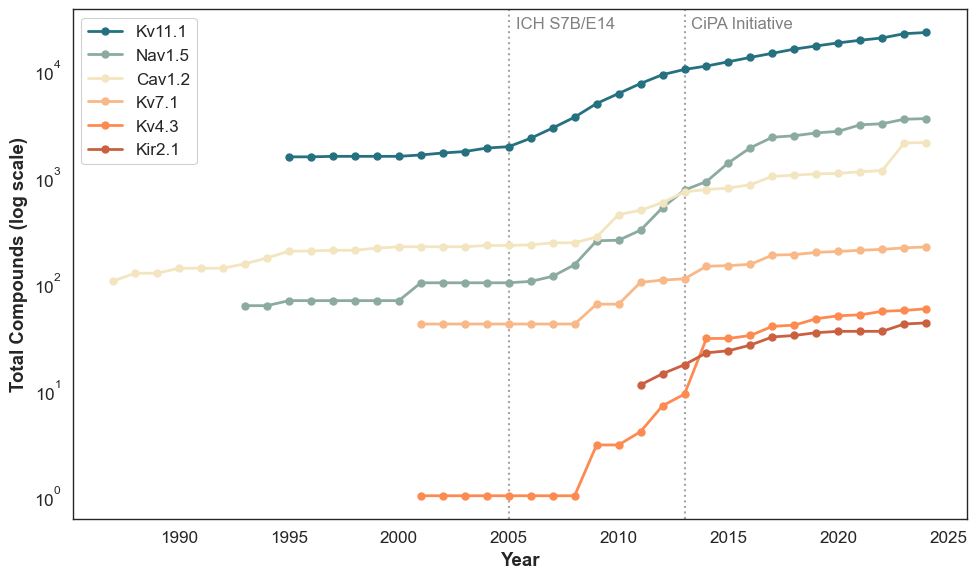

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

for channel in primary_channels:
    channel_data = df.filter(
        pl.col("Channel") == channel,
        pl.col("Compounds") > 0,
    )
    ax.plot(
        channel_data["Year"],
        channel_data['Compounds'],
        color=channel_colors[channel],
        linewidth=2,
        marker='o',
        markersize=5,
        label=channel
    )

plt.yscale("log")
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Total Compounds (log scale)', fontweight='bold')

ax.legend(loc='upper left', framealpha=0.9)

for year in VLINE_YEARS:
    ax.axvline(x=year, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)
    ax.annotate(
        VLINE_ANNOTATIONS[year],
        xy=(year, ax.get_ylim()[1]),
        xytext=(5, -5),
        textcoords='offset points',
        fontsize=12,
        color='gray',
        ha='left',
        va='top'
    )

plt.tight_layout()
plt.savefig('../figures/F2_ChEMBL_deposition_compounds.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/F2_ChEMBL_deposition_compounds.eps', dpi=300, bbox_inches='tight')
plt.show()

✔ Matplotlib is now using: Arial


/var/folders/x7/nt253mgd7cxcv4h4jqqbh32c0000gn/T/ipykernel_32637/1230206416.py:62: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 60000)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


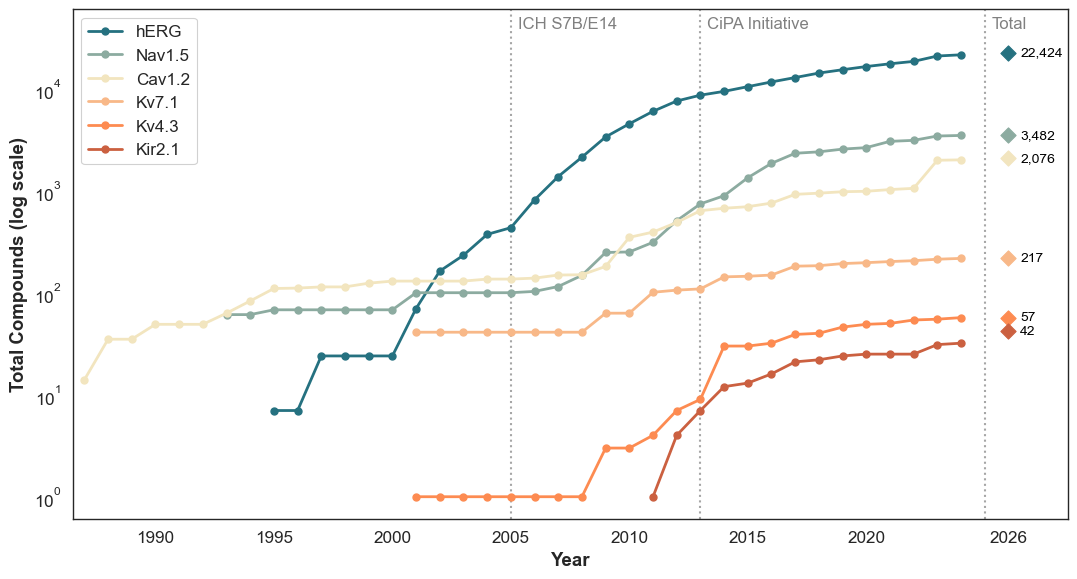

In [51]:
sns.set_style('white')
sns.set_context('paper', font_scale=1.4)
set_font()

primary_channels = ['hERG', 'Nav1.5', 'Cav1.2', 'Kv7.1', 'Kv4.3', 'Kir2.1']

VLINE_YEARS = [2005, 2013, 2025]
VLINE_ANNOTATIONS = {
    2005: "ICH S7B/E14",
    2013: "CiPA Initiative",
    2025: "Total"
}

palette = six_point_palette('hex')
channel_colors = {ch: palette[i % len(palette)] for i, ch in enumerate(primary_channels)}

df = read_pl("../results/compound_deposition_ionflow.tsv")
total = read_pl("../results/total_deposition_ionflow.tsv")

fig, ax = plt.subplots(figsize=(11, 6))

for channel in primary_channels:
    channel_data = df.filter(
        pl.col("Channel") == channel,
        pl.col("Compounds") > 0,
    ).sort("Year")

    color = channel_colors[channel]

    ax.plot(
        channel_data["Year"],
        channel_data["Compounds"],
        color=color,
        linewidth=2,
        marker="o",
        markersize=5,
        label=channel,
    )

    x_last = channel_data["Year"][-1]
    y_last = channel_data["Compounds"][-1]

    y_total = total.filter(pl.col("Channel") == channel)["Compounds"][0]

    ax.scatter(2026, y_total, color=color, marker="D", s=60, zorder=5)

    ax.text(
        2026.5, y_total,
        f"{y_total:,}",
        color="black",
        fontsize=10,
        va="center",
        ha="left",
    )

plt.yscale("log")
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Total Compounds (log scale)", fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)

plt.xlim(1986.5, 2028.5)
plt.ylim(0, 60000)

for year in VLINE_YEARS:
    ax.axvline(x=year, color="gray", linestyle=":", linewidth=1.5, alpha=0.7, zorder=1)
    ax.annotate(
        VLINE_ANNOTATIONS[year],
        xy=(year, ax.get_ylim()[1]),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=12,
        color="gray",
        ha="left",
        va="top",
    )

xticks = list(range(1990, 2025, 5)) + [2026]
xticklabels = [str(y) for y in range(1990, 2025, 5)] + ["2026"]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

plt.tight_layout()
plt.savefig("../figures/F2_ChEMBL_deposition_compounds.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/F2_ChEMBL_deposition_compounds.eps", dpi=300, bbox_inches="tight")
plt.show()

### ToC components

In [49]:
text = r"""
    Cavalli (2002) \cite{Cavalli2002}          & 3D Shape-based & hERG \\
    Ekins (2002) \cite{Ekins2002}              & 3D Shape-based (CATALYST) & hERG \\
    Roche (2002) \cite{Roche2002}              & MD (VolSurf, DRAGON) & hERG\\
    Ekins (2003) \cite{Ekins2003}              & 3D Shape-based (CATALYST) & hERG \\
    Keserü (2003) \cite{Keser2003}             & MD (VolSurf, Sybyl) & hERG\\
    \cmidrule{2-5}
    Pearlstein (2003) \cite{Pearlstein2003}    & Pharmacophore & hERG \\
    \cmidrule{2-5}
    Aptula (2004) \cite{Aptula2004}            & MD, Quantum Chemical & hERG \\
    \cmidrule{2-5}
    Aronov (2004) \cite{Aronov2004}            & Pharmacophore-based & hERG \\
    \cmidrule{2-5}
    Bains (2004) \cite{Bains2004}              & MD, Fragment-based  & hERG \\
    \cmidrule{2-5}
    Fioravanzo (2004) \cite{Fioravanzo2004}    & MD (DRAGON), EVA (from IR and Raman spectra), DRAGON & hERG \\
    \cmidrule{2-5}
    Cianchetta (2005) \cite{Cianchetta2005}    & 3D Shape-based & hERG \\
    \cmidrule{2-5}
    O'Brien (2005) \cite{OBrien2005}           & Topological, Fragment-based, Circular & hERG \\
    \cmidrule{2-5}
    Tobita (2005) \cite{Tobita2005}            & MD (MOE), MACCS & hERG \\
    \cmidrule{2-5}
    Aronov (2006) \cite{Aronov2006}            & 3D Shape-based (MOE) & hERG \\
    \cmidrule{2-5}
    Coi (2006) \cite{Coi2006}                  & MD (CODESSA) & hERG \\
    \cmidrule{2-5}
    Dubus (2006) \cite{Dubus2006}              & MD (MOE) & hERG \\
    \cmidrule{2-5}
    Ekins (2006) \cite{Ekins2006}              & MD (Smart Mining) & hERG \\
    \cmidrule{2-5}
    Gepp (2006) \cite{Gepp2006}                & MD, QC (VAMP), Custom SMARTS & hERG \\
    \cmidrule{2-5}
    Seierstad (2006) \cite{Seierstad2006}      & MD (MOE), Topological (KH, GC), Atom Pairs, Fragment (ISIDA) & hERG \\
    \cmidrule{2-5}
    Sun (2006) \cite{Sun2006}                  & Atom Types, Circular & hERG \\
    \cmidrule{2-5}
    Song (2006) \cite{Song2006}                & Fragment (Clark 2005) & hERG \\
    \cmidrule{2-5}
    Yoshida (2006) \cite{Yoshida2006}          & MD & hERG \\
    \cmidrule{2-5}
    Du (2007) \cite{Du2007}                    & Docking scores & hERG \\
    \cmidrule{2-5}
    Leong (2007) \cite{Leong2007}              & Pharmacophore & hERG \\
    \cmidrule{2-5}
    Obrezanova (2007) \cite{Obrezanova2007}    & MD (in-house), custom SMARTS & hERG \\
    \cmidrule{2-5}
    Chekmarev (2008) \cite{Chekmarev2008}      & 3D Shape-based & hERG \\
    \cmidrule{2-5}
    Gunturi (2008) \cite{Gunturi2008}          & MD (BioSuite, SYBYL) & hERG \\
    \cmidrule{2-5}
    Jia (2008) \cite{Jia2008}                  & Atom Types & hERG \\
    \cmidrule{2-5}
    Kramer (2008) \cite{Kramer2008}            & MD and QC & hERG \\
    \cmidrule{2-5}
    Li (2008) \cite{Li2008}                    & Field-based & hERG \\
    \cmidrule{2-5}
    Thai\sep (2008) \cite{Thai2008BMC}         & MD & hERG \\
    \cmidrule{2-5}
    Thai\sep (2008) \cite{Thai2008_CBDD}       & MD (MOE) & hERG \\
    \cmidrule{2-5}
    Wang (2008) \cite{Wang2008}                & 3D MD, QC & hERG \\
    \cmidrule{2-5}
    Coi (2009) \cite{Coi2009}                  & MD (CODESSA), QC (MOPAC) & hERG \\
    \cmidrule{2-5}
    Ermondi (2009) \cite{Ermondi2009}          & Field-based & hERG \\
    \cmidrule{2-5}
    Hansen (2009) \cite{Hansen2009}            & MD (MOE), Field-based, Pharmacophore & hERG \\
    \cmidrule{2-5}
    Nisius\sep (2009) \cite{Nisius2009CBDD}    & Fragment & hERG \\
    \cmidrule{2-5}
    Nisius\sep (2009) \cite{Nisius2009JCIM}    & Circular, Fragment, 3D-shape based & hERG \\
    \cmidrule{2-5}
    Thai (2009) \cite{Thai2009}                & MD (MOE, VolSurf), SIBAR & hERG \\
    \cmidrule{2-5}
    Doddareddy (2010) \cite{Doddareddy2010}    & Circular & hERG \\
    \cmidrule{2-5}
    Obrezanova (2010) \cite{Obrezanova2010}    & MD (in-house), custom SMARTS & hERG \\
    \cmidrule{2-5}
    Su (2010) \cite{Su2010}                    & 4D-FP (MDDM), MD (MOE) & hERG \\
    \cmidrule{2-5}
    Wiśniowska (2010) \cite{Wisniowska2010}    & MD, Circular, Experimental & hERG \\
    \cmidrule{2-5}
    Cuny (2011) \cite{Cuny2011}                & MD (MOE), Pharmacophore & hERG \\
    \cmidrule{2-5}
    Kim (2011) \cite{Kim2011}                  & MD, Circular & hERG \\
    \cmidrule{2-5}
    Obiol-Pardo (2011) \cite{ObiolPardo2011}   & Field-based, Docking Scores & hERG, Kv7.1 \\
    \cmidrule{2-5}
    Robinson (2011) \cite{Robinson2011}        & MD (MOE), Circular & hERG \\
    \cmidrule{2-5}
    Sinha (2011) \cite{Sinha2011}              & MD & hERG \\
    \cmidrule{2-5}
    Shen (2011) \cite{Shen2011}                & 4D-FP (MDDM), MD (MOE, VolSurf) & hERG \\
    \cmidrule{2-5}
    Broccatelli (2012) \cite{Broccatelli2012}  & MD (MOE, DRAGON, CDK), Field-based (VS+), Interaction (FLAP), Fragment & hERG \\
    \cmidrule{2-5}
    Kar (2012) \cite{Kar2012}                  & MD (PaDEL, Cerius2, DRAGON) & hERG \\
    \cmidrule{2-5}
    Polak (2012) \cite{Polak2012}              & MD (ChemAxon) & Kv7.1 \\
    \cmidrule{2-5}
    Tan (2012) \cite{Tan2012}                  & MD (CODESSA), QC (MOPAC), Pharmacophore & hERG \\
    \cmidrule{2-5}
    Wang (2012) \cite{Wang2012}                & Circular, Path-based & hERG \\
    \cmidrule{2-5}
    Wiśniowska (2012) \cite{Winiowska2012}     & MD (ChemAxon) & Cav1.2 \\
    \cmidrule{2-5}
    Czodrowski (2013) \cite{Czodrowski2013}    & MD (RDKit) & hERG \\
    \cmidrule{2-5}
    Kireeva (2013) \cite{Kireeva2013}          & Fragment (IPLF), Path-based (CDK) & hERG \\
    \cmidrule{2-5}
    Braga (2014) \cite{Braga2014}              & Circular, Fragment (MACCS, PubChem), Pharmacophore & hERG \\
    Kratz (2014) \cite{Kratz2014}              & Pharmacophore (LigandScout, StudioCatalyst) & hERG \\
    \cmidrule{2-5}
    Liu (2014) \cite{Liu2014}                  & MD, Circular & hERG \\
    \cmidrule{2-5}
    Braga (2015) \cite{Braga2015}              & Circular, Path-based (CDK) & hERG \\
    \cmidrule{2-5}
    Du (2015) \cite{Du2015}                    & MD, Circular & hERG \\
    \cmidrule{2-5}
    Ma (2015) \cite{Ma2015}                    & MD, Circular, Fragment (MACCS), AtomPairs & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Chavan (2016) \cite{Chavan2016}            & Path-based (CDK), Topological (EState), Fragment (MACCS, PubChem, SubFP) & hERG \\
    \cmidrule{2-5}
    Didziapetris (2016) \cite{Didzia2016}      & Topological, Physicochemical & hERG \\
    \cmidrule{2-5}
    Gobbi (2016) \cite{Gobbi2016}              & String-fragment & hERG \\
    \cmidrule{2-5}
    Sheridan (2016) \cite{Sheridan2016}        & Atom Pairs, Donor-Acceptor Pairs & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Wang (2016) \cite{Wang2016}                & Pharmacophore (DS2.5) & hERG \\
    \cmidrule{2-5}
    Zhang (2016) \cite{Zhang2016}              & MD (PaDEL), Path-based (CDK), Fragment (MACCS, PubChem, SubFP) & hERG \\
    \cmidrule{2-5}
    Chemi (2017) \cite{Chemi2017}              & Pharmacophore & hERG \\
    \cmidrule{2-5}
    Li (2017) \cite{Li2017}                    & MD (DRAGON, ChemAxon), Path-based (CDK), Topological (EState), & hERG \\
    \cmidrule{2-5}
    Sun (2017) \cite{Sun2017}                  & Atom Types & hERG \\
    \cmidrule{2-5}
    Alves (2018) \cite{Alves2018}              & MD (PaDEL, DRAGON), Circular, Fragment (SiRMS) & hERG \\
    \cmidrule{2-5}
    Munawar (2018) \cite{Munawar2018}          & Field-based (GRIND) & hERG \\
    \cmidrule{2-5}
    Siramshetty (2018) \cite{Siramshetty2018}  & Circular, Fragment (MACCS, PubChem) & hERG \\
    \cmidrule{2-5}
    Wacker (2018) \cite{Wacker2018}            & MD (RDKit), Pharmacophore &  hERG \\
    \cmidrule{2-5}
    Yang (2018) \cite{Yang2018}                & Circular, Fragment (MACCS), Atom Pairs &  hERG \\
    \cmidrule{2-5}
    Cai (2019) \cite{Cai2019}                  & MD (MOE), Embedding (Mol2Vec) & hERG \\
    \cmidrule{2-5}
    Hu (2019) \cite{Hu2019}                    & Circular, Graphs & hERG \\
    \cmidrule{2-5}
    Konda (2019) \cite{Konda2019}              & MD (PaDEL) & hERG \\
    \cmidrule{2-5}
    Lee (2019) \cite{Lee2019}                  & MD (DRAGON), Circular & hERG \\
    \cmidrule{2-5}
    Munawar (2019) \cite{Munawar2019}          & Interaction-based (PLIF) & hERG \\
    \cmidrule{2-5}
    Negami (2019) \cite{Negami2019}            & FEP-based (MP-CAFEE) & hERG \\
    \cmidrule{2-5}
    Ogura (2019) \cite{Ogura2019}              & MD (MOE, PipelinePilot), Circular & hERG \\
    \cmidrule{2-5}
    Zhang (2019) \cite{Zhang2019}              & MD (ChemoPy, MOE, PaDEL) & hERG \\
    \cmidrule{2-5}
    Choi (2020) \cite{Choi2020}                & Circular, Path-based (CDK) & hERG \\
    Khalifa (2020) \cite{Khalifa2020}          & Atom Pairs & Nav1.5 \\
    \cmidrule{2-5}
    Kim (2020) \cite{Kim2020}                  & Circular & hERG \\
    \cmidrule{2-5}
    Liu (2020) \cite{Liu2020}                  & Atom Pairs, Topological (EState), Fragment (MACCS, Klek, PubChem), Path-based (FP4, FP4C), MD (PaDEL) & hERG \\
    \cmidrule{2-5}
    Ryu (2020) \cite{Ryu2020}                  & MD (Mordred), Circular, Fragment (PubChem), Graphs & hERG \\
    \cmidrule{2-5}
    Siramshetty (2020) \cite{Siramshetty2020}  & MD (RDKit), Circular, Embedding (AE) & hERG \\
    \cmidrule{2-5}
    Wang (2020) \cite{Wang2020}                & MD, Fragment (MACCS) & hERG \\
    \cmidrule{2-5}
    Creanza (2021) \cite{Creanza2021}          & Docking Scores (GLIDE, GOLD), Interactions (PLIF) & hERG \\
    \cmidrule{2-5}
    Karim (2021) \cite{Karim2021}              & MD (Mordred), Circular, Embeddings (Smi2Vec, FP2Vec), Fragment (PubChem), Graph &hERG \\
    \cmidrule{2-5}
    Lee (2021) \cite{Lee2021}                  & MD (RDKit), Pharmacophore & hERG \\
    \cmidrule{2-5}
    Meng (2021) \cite{Meng2021}                & Interaction, Circular, Fragment (MACCS), Topological (EState) & hERG \\
    \cmidrule{2-5}
    Moorthy (2021) \cite{Moorthy2021}          & MD (MOE), Fragment (MACCS) & hERG \\
    \cmidrule{2-5}
    Sato (2021) \cite{Sato2021}                & MD (RDKit, Mordred), Path-based (CDK), Circular & hERG \\
    \cmidrule{2-5}
    Stergiopoulos (2021) \cite{Stergio2021}    & MD, Experimental ($\alpha-1-acid-GP$ binding, IAM permeability) & hERG \\
    \cmidrule{2-5}
    Wu (2021) \cite{Wu2021}                  & Graphs & hERG \\
    \cmidrule{2-5}
    Xiong (2021) \cite{Xiong2021}            & Graphs & hERG \\
    \cmidrule{2-5}
    Arab (2022) \cite{Arab2022}              & MD (PaDEL) & hERG, Nav1.5 \\
    \cmidrule{2-5}
    Delre (2022) \cite{Delre2022}            & MD (DRAGON) & hERG \\
    \cmidrule{2-5}
    Ding (2022) \cite{Ding2022}              & MD, Circular, 3D Shape-based, 4D Dynamics-based & hERG \\
    \cmidrule{2-5}
    Ishihara (2022) \cite{Ishihara2022}      & MD (RDKit, Mordred) & hERG \\
    \cmidrule{2-5}
    Kim (2022) \cite{Kim2022}                & Graphs & hERG \\
    \cmidrule{2-5}
    Kong (2022) \cite{Kong2022}              & Path-based (CDK), Topological (EState), Fragment (MACCS, PubChem) & Nav1.5 \\
    \cmidrule{2-5}
    Krishna (2022) \cite{Krishna2022}        & MD (RDKit, OPERA) & hERG \\
    \cmidrule{2-5}
    Lanevskij (2022) \cite{Lanevskij2022}    & MD & hERG \\
    \cmidrule{2-5}
    Melnikov (2022) \cite{Melnikov2022}      & MD (RDKit), Circular, Fragment (MACCS), Topological Torsion & hERG \\
    Shan (2022) \cite{Shan2022}              & MD (RDKit, MOE), Circular, Fragment (MACCS, PubChem), Embedding (Mol2Vec) & hERG \\
    \cmidrule{2-5}
    Zhang (2022) \cite{Zhang2022}            & Circular, Fragment (MACCS) & hERG \\
    \cmidrule{2-5}
    Arab (2023) \cite{Arab2023}              & MD (Mordred), Circular, Fragment (PubChem), Graphs & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Banerjee (2023) \cite{Banerjee2023}      & MD, Similarity (RASAR) & hERG \\
    \cmidrule{2-5}
    Chen (2023) \cite{Chen2023}              & MD (RDKit), Circular, Atom Pairs, Fragment (MACCS), Topological Torsion & hERG \\
    \cmidrule{2-5}
    Das (2023) \cite{Das2023}                & MD (PaDEL), Path-based (CDK) & hERG \\
    \cmidrule{2-5}
    Feng (2023) \cite{Feng2023}              & 3D Shape-based, Embedding (CDDD, Transformer) & hERG \\
    \cmidrule{2-5}
    Wang\sep (2023) \cite{Wang2023_CBM}      & Path-based (CDK), Circular, Fragment (PubChem), Atom Pairs, SMILES & hERG \\
    \cmidrule{2-5}
    Wang\sep (2023) \cite{Wang2023_FiP}      & Circular, Graphs & hERG \\
    \cmidrule{2-5}
    Vittorio (2023) \cite{Vittorio2023}      & MD, Circular & hERG \\
    \cmidrule{2-5}
    Ylipää (2023) \cite{Ylipaa2023}          & MD (Mordred), Graphs, SMILES & hERG \\
    \cmidrule{2-5}
    Arab (2024) \cite{Arab2024}              & MD (Mordred), Circular, Fragment (PubChem) & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Chen (2024) \cite{Chen2024}              & Fragment (MACCS) & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    He (2024) \cite{He2024}                  & SMILES & hERG \\
    \cmidrule{2-5}
    Liu (2024) \cite{Liu2024}                & MD (Mold2) & hERG \\
    \cmidrule{2-5}
    Sanches (2024) \cite{Sanches2024}        & Circular & hERG \\
    \cmidrule{2-5}
    Wang (2024) \cite{Wang2024}              & Circular, Fragment (MACCS, PubChem), Graphs, Embedding (Smi2Vec), Pharmacophore & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Yang (2024) \cite{Yang2024}              & Graphs & hERG \\
    \cmidrule{2-5}
    Cano (2025) \cite{Cano2025}              & MD (MOE, alvaDesc), Topological (Kappa), Circular, Fragment (MACCS) & hERG \\
    \cmidrule{2-5}
    Feng (2025) \cite{Feng2025}              & Circular, Fragment (PubChem, MACCS), Graphs, SMILES, Pharmacophore & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Gambacorta (2025) \cite{Gambacorta2025}  & Fragment (CSFP) & ERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Han (2025) \cite{Han2025}                & Circular & hERG \\
    \cmidrule{2-5}
    Hossain (2025) \cite{Hossain2025}        & MD (Morgan), Path-based (CDK), Embeddings (MegaMolBART, LLaMA3.2, Gemini, QWEN1.5b) & hERG \\
    \cmidrule{2-5}
    Jin (2025) \cite{Jin2025}                & MD, Circular, Fragment (MACCS), Graphs, Path-based (RDKit) & hERG \\
    Jing (2025) \cite{Jing2025}              & MD, Atom Types (AMBER), Circular, Fragment (MACCS), Atom Pairs, Topological Torsion  & hERG \\
    \cmidrule{2-5}
    Kyro (2025) \cite{Kyro2025}              & MD (RDKit), Circular, Graphs, Embeddings (BDT) & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Lee (2025) \cite{Lee2025}                & MD, Circular, Graphs & hERG \\
    \cmidrule{2-5}
    Liu\sep (2025) \cite{K_Liu2025}          & MD (RDKit), Circular, Fragment (MACCS), Atom Pairs, Path-based (FP2) & hERG \\
    \cmidrule{2-5}
    Liu\sep (2025) \cite{L_Liu2025}          & Circular, Graphs, Images & hERG \\
    \cmidrule{2-5}
    Mohammad (2025) \cite{Mohammad2025}      & MD (RDKit, Avalon), Path-based (CDK), Embeddings (Mol2Vec), Fragment (MACCS, Klek), Atom Pair & hERG \\
    \cmidrule{2-5}
    Tran-Nguyen (2025) \cite{TranNguyen2025} & Interaction (PLEC) & hERG \\
    \cmidrule{2-5}
    Xu (2025) \cite{Xu2025}                  & Embeddings (GROVER, kBERT, GIN, Chemprop), Various (RDKit, DeepChem, MolMap, Mordred) & hERG \\
    \cmidrule{2-5}
    Yang (2025) \cite{Yang2025}              & Circular & hERG \\
    \cmidrule{2-5}
    Yu (2025) \cite{Yu2025}                  & MD (AlvaDesc), Circular & hERG \\
    \cmidrule{2-5}
    Zhang (2025) \cite{Zhang2025}            & MD (Avalon), Circular, Fragment (MACCS), Graphs & hERG \\
    \cmidrule{2-5}
    Agarwal (2026) \cite{Agarwal2026}        & Graph & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Beidja (2026) \cite{Beidja2026}          & SMILES, Graphs, Circular, Atom Pairs, Fragment (PubChem, Klek), Topological Torsion & hERG \\
    \cmidrule{2-5}
    Chu (2026) \cite{Chu2026}                & Images, Graphs, Circular, Pharmacophore & hERG \\
    \cmidrule{2-5}
    Enokiya (2026) \cite{Enokiya2026}        & Graphs, MD (Mordred, RDKit), FAERS signals & hERG \\
    \cmidrule{2-5}
    Jovanocić (2026) \cite{Jovanovi2026}     & Embeddings (ChemBERTa, L1000), Circular, Atom Pair, Topological Torsion, MD (RDKit, MolGpKa) & hERG, Nav1.5, Cav1.2, Kv7.1 \\
    \cmidrule{2-5}
    Liang (2026) \cite{Liang2026}            & Graphs, Circular, Fragment (MACCS),  MD (RDKit) & hERG, Nav1.5, Cav1.2 \\
    \cmidrule{2-5}
    Su (2026) \cite{Su2026}                  & Fragment (MACCS, PubChem, SubFP), Pharmacophore & hERG \\
    \cmidrule{2-5}
    Zhang (2026) \cite{Zhang2026}            & Graphs, Circular, Pharmacophore & hERG \\
    \cmidrule{2-5}
    Zhao (2026) \cite{Zhao2026}              & MD (Mordred), Circular, Fragment (MACCS, PubChem), Graphs, SMILES, Interaction (PLIF) & hERG"""

In [50]:
text = text.replace(r"\cmidrule{2-5}", "")

In [51]:
from collections import defaultdict
import re
ddc = defaultdict(list)
lines = [line.replace(r"\n", "").strip() for line in text.split(r"\\")]

In [52]:
lines[0]

'Cavalli (2002) \\cite{Cavalli2002}          & 3D Shape-based & hERG'

In [53]:
import polars as pl

for line in lines:
    print(line)
    auth, desc, chan = line.split("&")
    auth, year, cite = (re.sub(r"\s+", " ", auth).strip().split(" "))
    ddc["Auth"].append(auth.strip())
    ddc["Year"].append(year.strip())
    ddc["Desc"].append(desc.strip())
    ddc["Chan"].append(chan.strip())

df = pl.DataFrame(ddc).with_columns(
    pl.col("Year").map_elements(
        lambda year: year[1:-1],
        return_dtype=pl.String
    )
).cast({"Year": pl.Int32})


Cavalli (2002) \cite{Cavalli2002}          & 3D Shape-based & hERG
Ekins (2002) \cite{Ekins2002}              & 3D Shape-based (CATALYST) & hERG
Roche (2002) \cite{Roche2002}              & MD (VolSurf, DRAGON) & hERG
Ekins (2003) \cite{Ekins2003}              & 3D Shape-based (CATALYST) & hERG
Keserü (2003) \cite{Keser2003}             & MD (VolSurf, Sybyl) & hERG
Pearlstein (2003) \cite{Pearlstein2003}    & Pharmacophore & hERG
Aptula (2004) \cite{Aptula2004}            & MD, Quantum Chemical & hERG
Aronov (2004) \cite{Aronov2004}            & Pharmacophore-based & hERG
Bains (2004) \cite{Bains2004}              & MD, Fragment-based  & hERG
Fioravanzo (2004) \cite{Fioravanzo2004}    & MD (DRAGON), EVA (from IR and Raman spectra), DRAGON & hERG
Cianchetta (2005) \cite{Cianchetta2005}    & 3D Shape-based & hERG
O'Brien (2005) \cite{OBrien2005}           & Topological, Fragment-based, Circular & hERG
Tobita (2005) \cite{Tobita2005}            & MD (MOE), MACCS & hERG
Aronov (2006) \cite

In [54]:
chan_map = {
    'Kv7.1': 'Non-hERG',
    'hERG, Nav1.5': 'Multi-channel',
    'Nav1.5': 'Non-hERG',
    'hERG, Nav1.5, Cav1.2': 'Multi-channel',
    'hERG, Kv7.1': 'Multi-channel',
    'hERG': 'hERG',
    'hERG, NaV1.5, CaV1.2': 'Multi-channel',
    'Cav1.2': 'Non-hERG',
    'ERG, Nav1.5, Cav1.2': 'Multi-channel',
    "hERG, Nav1.5, Cav1.2, Kv7.1": "Multi-channel",
}

df = df.with_columns(
    pl.col("Chan").map_elements(
        lambda chan: chan_map.get(chan),
        return_dtype=pl.String
    ).alias("Study Type")
)

In [55]:
import pandas as pd

df = df.with_columns(
    pl.when(
        pl.col("Year") <= 2008
    ).then(pl.lit("Foundation\n(2001-2008)"))
    .when(
        pl.col("Year") <= 2018
    ).then(pl.lit("Consolidation\n(2009-2018)"))
    .otherwise(
        pl.lit("Expansion\n(2019-2026)")
    ).alias("Period")
)

pdf = df.group_by(["Period", "Study Type"]).agg(
    pl.len().alias("No Studies")
)
pdf = pdf.to_pandas()

period_dtype = pd.CategoricalDtype(["Foundation\n(2001-2008)", "Consolidation\n(2009-2018)", "Expansion\n(2019-2026)"], ordered=True)
study_dtype = pd.CategoricalDtype(["Non-hERG", "Multi-channel", "hERG"], ordered=True)

pdf = pdf.astype({
    "Period": period_dtype,
    "Study Type": study_dtype
})

✔ Matplotlib is now using: Arial


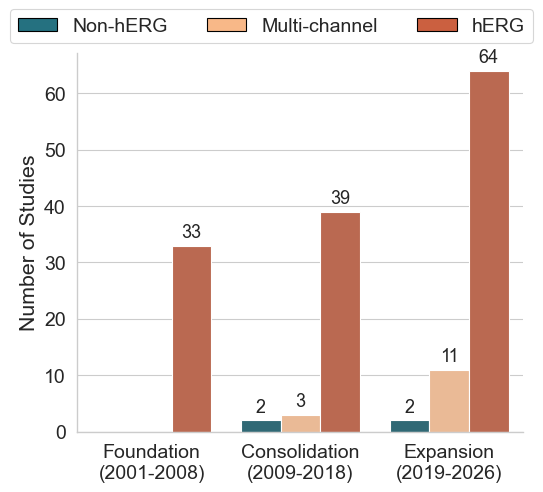

In [56]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from novami.visualize.utils import six_point_palette, set_font

pal = six_point_palette()

study_palette = {
    "Non-hERG": pal[0],
    "Multi-channel": pal[3],
    "hERG": pal[-1]
}

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.6)
set_font()

g = sns.catplot(pdf, x="Period", y="No Studies", kind='bar', hue="Study Type", legend=False, aspect=1.1, palette=study_palette)
plt.xlabel("")

labels = ["Non-hERG", "Multi-channel", "hERG"]
handles = [Patch(label=label, edgecolor="black", facecolor=study_palette.get(label)) for label in labels]
plt.legend(labels=labels, handles=handles, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.06), bbox_transform=g.figure.transFigure)
plt.ylabel("Number of Studies")

ax = g.ax

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues],
        padding=3,
        fontsize=13
    )

g.figure.savefig(
    "../figures/study_types_by_period.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=1200
)

In [64]:
df["Chan"].value_counts()

Chan,count
str,u32
"""Nav1.5""",2
"""hERG, Nav1.5, Cav1.2""",10
"""hERG, Nav1.5, Cav1.2, Kv7.1""",1
"""Cav1.2""",1
"""ERG, Nav1.5, Cav1.2""",1
"""Kv7.1""",1
"""hERG, Nav1.5""",1
"""hERG, Kv7.1""",1
"""hERG""",136


In [65]:
15/154

0.09740259740259741

### Methods

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import polars as pl
from novami.io import read_pl
from novami.visualize.utils import six_point_palette

def get_gene(name_list):
    for gene in ["KCNH2", "CACNA1C", "SCN5A", "KCNJ2", "KCND3", "KCNQ1"]:
        if gene in name_list:
            return gene

channel_map = {
    "KCNH2": "Kv11.1",
    "CACNA1C": "Cav1.2",
    "SCN5A": "Nav1.5",
    "KCNJ2": "Kir2.1",
    "KCNQ1": "Kv7.1",
    "KCND3": "Kv4.3"
}

In [4]:
df = read_pl("../data/chembl36/2_assay_annotated/06_paper_check_validated.xlsx")[["assay_chembl_id", "assay_description", "gene_name", "#Compounds", "Mechanism", "Readout"]]

df = df.filter(
    pl.col("gene_name").str.split(";").map_elements(
        lambda lst: any(gene in lst.to_list() for gene in ["KCNH2", "CACNA1C", "SCN5A", "KCNJ2", "KCND3", "KCNQ1"]),
        return_dtype=pl.Boolean)
)

df = df.filter(
    (~pl.col("Mechanism").is_in(["SUS", "CON"])) & (~pl.col("Readout").is_in(["SUS", "CON"]))
)

df = df.with_columns(
    pl.col("gene_name").str.split(";").map_elements(
        get_gene, return_dtype=pl.String
    ).alias("ParentGene"),
    pl.col("Mechanism").str.split("_").list.first().alias("MechanismParent"),
    pl.col("Readout").str.split("_").list.first().alias("ReadoutParent")
)

df = df.with_columns(
    pl.col("ParentGene").map_elements(lambda gene: channel_map.get(gene), return_dtype=pl.String).alias("Channel")
)

df = df.group_by(["Channel", "Mechanism", "Readout"]).agg(pl.col("#Compounds").sum().alias("Measurements"))


df_cnt = df["Measurements"].sum()


df = df.with_columns(
    (pl.col("Measurements") / df_cnt * 100).round(2).alias("%Measurements")
)

Could not determine dtype for column 38, falling back to string


In [5]:
resolved = [
    ('EC', 'EL_PC_A'), ('IF_RB', 'RA'), ('IF_TL', 'FL_DY'), ('EC', 'EL_TE'),
    ('LB_RL', 'RA'), ('MP', 'FL_DY'), ('IF_RB', 'AAS'), ('EC', 'EL_PC_M'),
    ('IF_GU', 'RA'), ('EC', 'EL_PC_P'), ('IIC_NA', 'FL_DY'), ('IF_TL', 'FL'),
    ('EC', 'EL_PC_PF'), ('MP', 'FL_FR'), ('IIC_CA', 'FL_DY'), ('LB_FT', 'FL_FP'),
]

df = df.with_columns(
    pl.struct(["Mechanism", "Readout"]).map_elements(
        lambda tpl: (tpl["Mechanism"], tpl["Readout"]) in resolved,
        return_dtype=pl.Boolean
    ).alias("Resolved")
)

df = df.with_columns(
    pl.col("Mechanism").str.split("_").list.first().alias("MechanismP"),
    pl.col("Readout").str.split("_").list.first().alias("ReadoutP"),
)

df = df.group_by(["Channel", "MechanismP", "ReadoutP", "Resolved"]).agg(
    pl.col("Measurements").sum().alias("Measurements")
)

df = df.with_columns(
    pl.concat_str(pl.col("MechanismP"), pl.col("ReadoutP"), separator=" / ").alias("Pair")
)

In [6]:
mechanism_map = {
    "MP": "Membr. Pot.",
    "LB": "Lig. Bind.",
    "IF": "Ion Flux",
    "IIC": "Int. Ion Conc.",
    "EC": "Elect. Curr.",
    "AMB": "Ambiguous"
}

readout_map = {
    "EL": "Electric",
    "FL": "Flouresc.",
    "AMB": "Ambiguous",
    "RA": "Radioact.",
    "BP": "BioPhys.",
    "AAS": "AAS"
}


In [7]:
df = df.with_columns(
    pl.col("MechanismP").map_elements(lambda desc: mechanism_map.get(desc), return_dtype=pl.String).alias("Mechanism"),
    pl.col("ReadoutP").map_elements(lambda desc: readout_map.get(desc), return_dtype=pl.String).alias("Readout")
)

In [8]:
pal = six_point_palette()

from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "custom",
    [(0.0, pal[-1]), (0.7, pal[2]), (1.0, pal[0])]
)

sns.set_context("paper", font_scale=1.4)
sns.set_style("white")

In [12]:
(df["Measurements"] * df["Resolved"]).sum() / df["Measurements"].sum()

0.5738242704178039

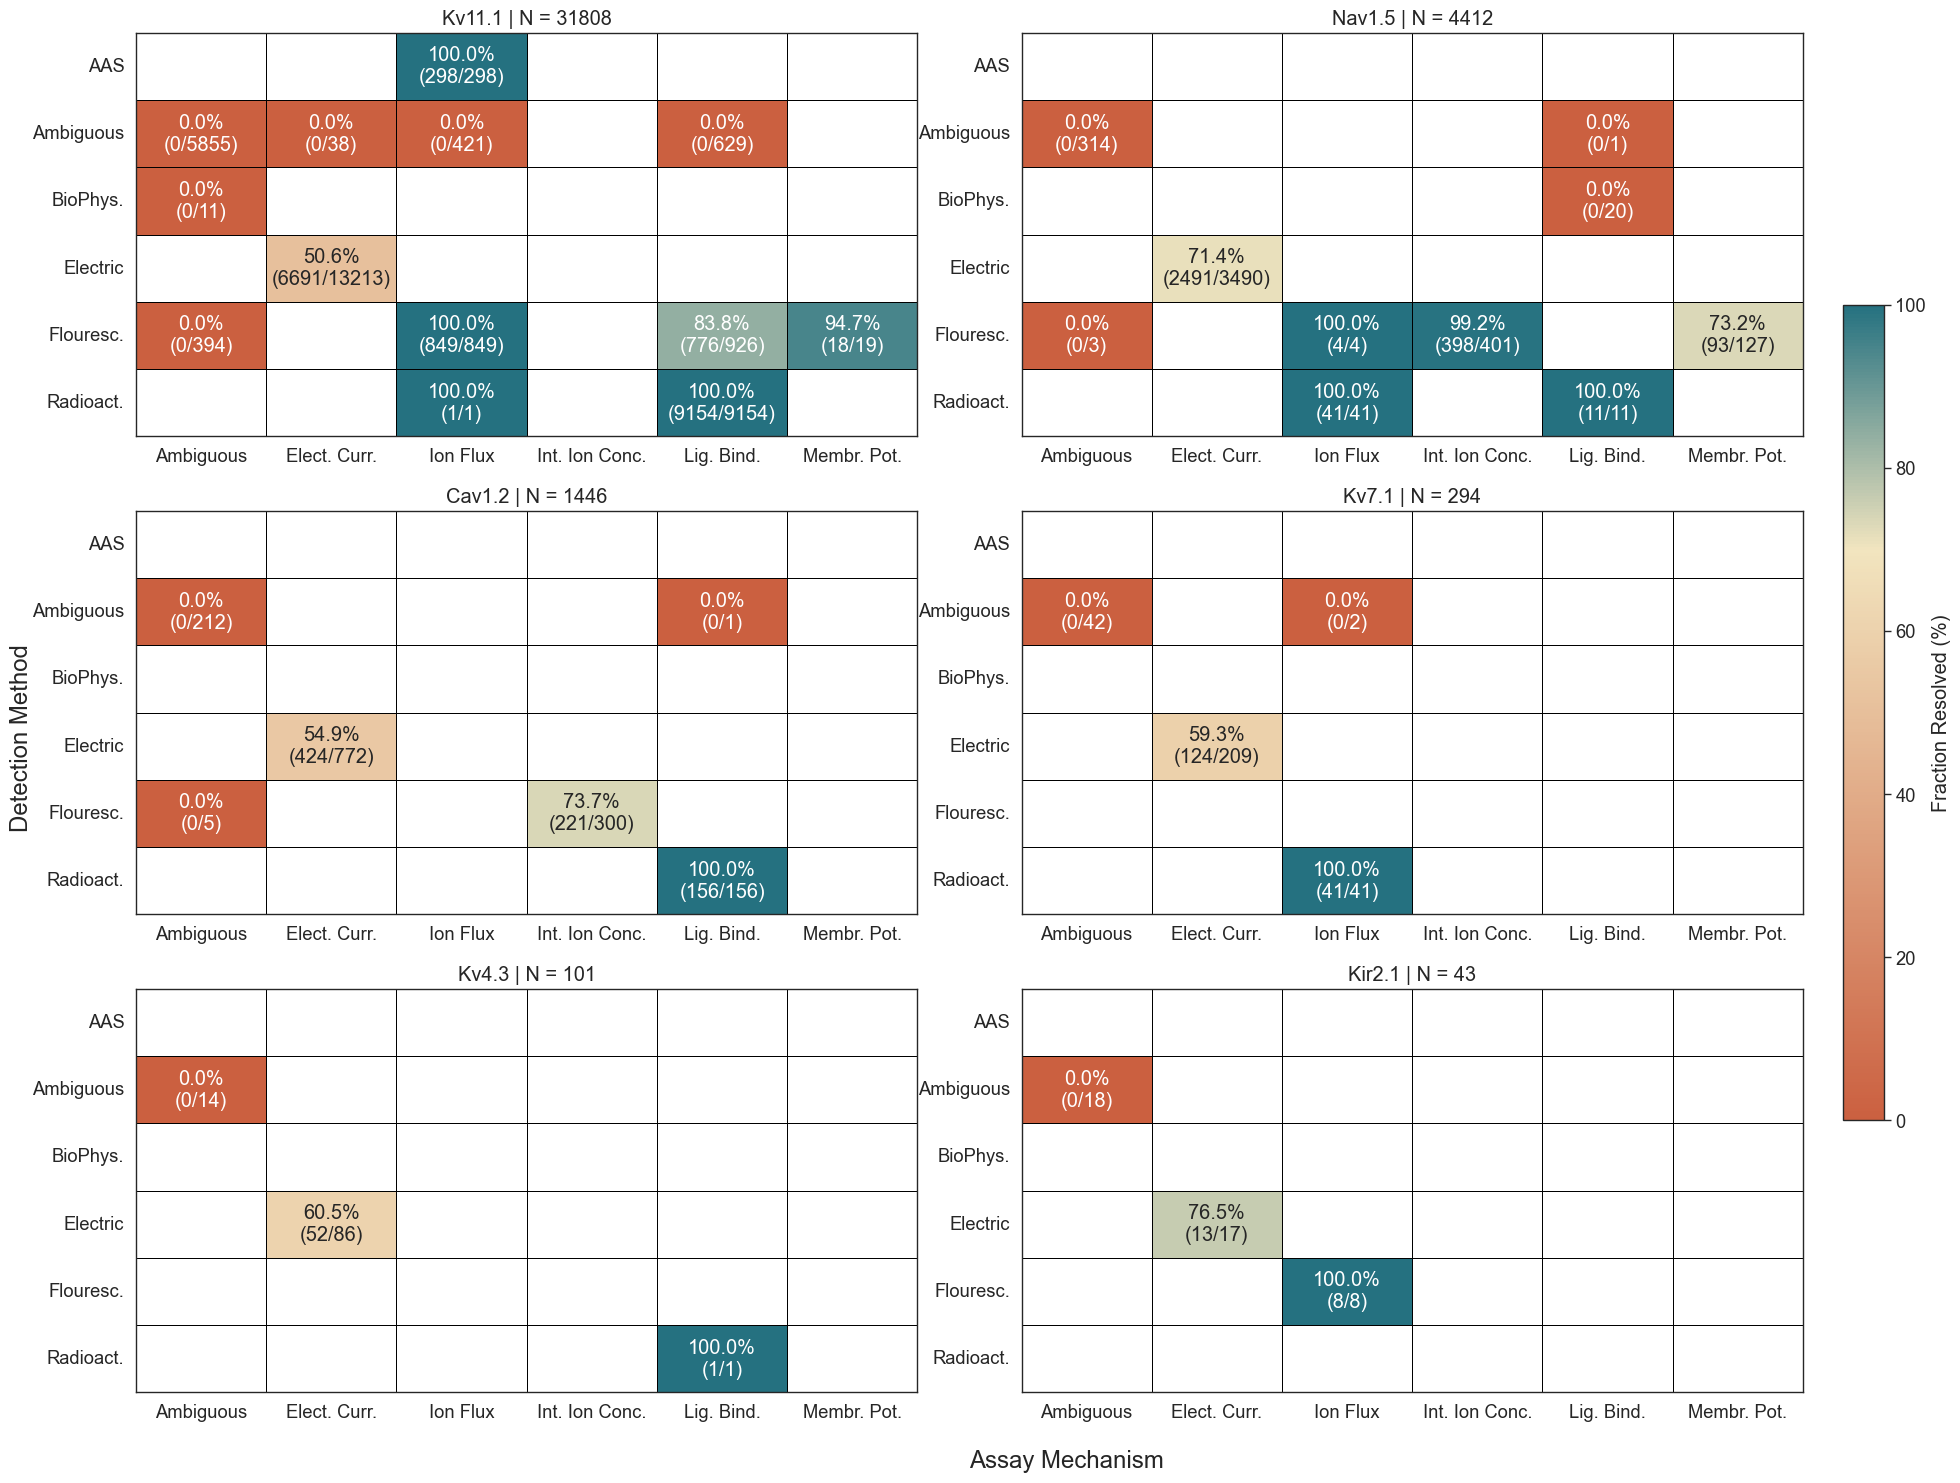

In [254]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Colormap ---
pal = six_point_palette()
cmap = LinearSegmentedColormap.from_list(
    "custom",
    [(0.0, pal[-1]), (0.7, pal[2]), (1.0, pal[0])]
)
cmap.set_bad("white")  # NaN → white (exists elsewhere, not in this channel)

# --- Existing combinations ---
existing_combo_strings = [
    'IIC / FL', 'IF / FL', 'LB / FL', 'AMB / FL', 'IF / AMB', 'LB / AMB',
    'MP / FL', 'IF / AAS', 'LB / BP', 'LB / RA', 'IF / RA', 'AMB / BP',
    'EC / AMB', 'EC / EL', 'AMB / AMB'
]
existing_pairs = {tuple(s.split(" / ")) for s in existing_combo_strings}
all_mechanisms = sorted(set(p[0] for p in existing_pairs))
all_readouts   = sorted(set(p[1] for p in existing_pairs))

# --- Global mask: combinations that don't exist in any channel ---
global_mask = pd.DataFrame(False, index=all_readouts, columns=all_mechanisms)
for row in all_readouts:
    for col in all_mechanisms:
        if (col, row) not in existing_pairs:
            global_mask.loc[row, col] = True

# --- Short code → full description mappings ---
mechanism_map = dict(df.select(["MechanismP", "Mechanism"]).unique().iter_rows())
readout_map   = dict(df.select(["ReadoutP",   "Readout"  ]).unique().iter_rows())

def reindex_matrix(pdf):
    return pdf.reindex(index=all_readouts, columns=all_mechanisms)

# --- Plot ---
sns.set_context("paper", font_scale=1.5)
sns.set_style("white")

g = sns.FacetGrid(
    data=df, col="Channel", sharex=False, sharey=False,
    aspect=2.2, height=5, col_wrap=2,
    col_order=["Kv11.1", "Nav1.5", "Cav1.2", "Kv7.1", "Kv4.3", "Kir2.1"]
)

for ax in g.axes.flatten():
    chan = ax.title.get_text().split(" = ")[1]
    sub_df = df.filter(pl.col("Channel") == chan)

    # Total measurements per group (all rows)
    sums = sub_df.group_by(["MechanismP", "ReadoutP"]).agg(
        pl.col("Measurements").sum().alias("MeasurementsSum")
    )

    # Resolved measurements per group (only resolved rows)
    resolved_sums = (
        sub_df.filter(pl.col("Resolved"))
        .group_by(["MechanismP", "ReadoutP"])
        .agg(pl.col("Measurements").sum().alias("ResolvedMeasurements"))
    )

    # Left join so AMB (0 resolved) is still present, just with 0 resolved count
    combined = (
        sums
        .join(resolved_sums, on=["MechanismP", "ReadoutP"], how="left")
        .with_columns([
            pl.col("ResolvedMeasurements").fill_null(0),
            (pl.col("ResolvedMeasurements").fill_null(0) / pl.col("MeasurementsSum") * 100)
            .round(2)
            .alias("Fraction")
        ])
    )

    m_count = combined["MeasurementsSum"].sum()

    matrix_frac = reindex_matrix(combined.pivot(on="MechanismP", index="ReadoutP", values="Fraction").to_pandas().set_index("ReadoutP"))
    matrix_meas = reindex_matrix(combined.pivot(on="MechanismP", index="ReadoutP", values="ResolvedMeasurements").to_pandas().set_index("ReadoutP")).fillna(0).astype(int)
    matrix_sum  = reindex_matrix(combined.pivot(on="MechanismP", index="ReadoutP", values="MeasurementsSum").to_pandas().set_index("ReadoutP")).fillna(0).astype(int)

    annot = pd.DataFrame("", index=all_readouts, columns=all_mechanisms)
    for row in all_readouts:
        for col in all_mechanisms:
            if global_mask.loc[row, col]:
                annot.loc[row, col] = ""
            elif pd.isna(matrix_frac.loc[row, col]):
                annot.loc[row, col] = "0/0"
            else:
                frac  = matrix_frac.loc[row, col]
                meas  = matrix_meas.loc[row, col]
                total = matrix_sum.loc[row, col]
                annot.loc[row, col] = f"{frac:.1f}%\n({meas}/{total})"

    sns.heatmap(
        matrix_frac.rename(columns=mechanism_map, index=readout_map),
        ax=ax,
        annot=annot.rename(columns=mechanism_map, index=readout_map),
        fmt="",
        cmap=cmap, vmin=0, vmax=100,
        cbar=False,
        linecolor="black", linewidths=0.5,
        mask=global_mask.rename(columns=mechanism_map, index=readout_map),
    )

    ax.set_title(f"{chan} | N = {m_count}")
    ax.set_xlabel("")
    ax.set_ylabel("")

    for _, spine in ax.spines.items():
        spine.set_visible(True)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])

g.figure.supxlabel("Assay Mechanism")
g.figure.supylabel("Detection Method")

plt.tight_layout()

g.figure.colorbar(sm, ax=g.axes.ravel().tolist(), label="Fraction Resolved (%)", shrink=0.6, pad=0.02)
plt.savefig("../figures/methods.png", dpi=300, bbox_inches="tight")

In [118]:
matrix = sub_df.pivot(
    on="ReadoutP",
    index="MechanismP",
    values="Fraction"
).fill_null(0.0)

In [142]:
from matplotlib.colors import LinearSegmentedColormap

pal = six_point_palette()

cmap = LinearSegmentedColormap.from_list(
    "custom",
    pal
)

<Axes: ylabel='MechanismP'>

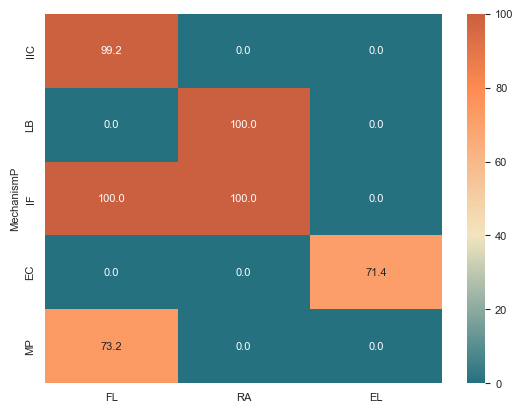

In [143]:
sns.heatmap(matrix.to_pandas().set_index("MechanismP"), annot=True, fmt=".1f", cmap=cmap)

In [137]:
sns.heatmap(matrix)

ValueError: could not convert string to float: 'IIC'